# 请大家先看视频，再结合代码进行思考

In [1]:
# 1. 环境准备与库导入
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# 2. 请根据实际修改文件路径
input_path = '../data/user_personalized_features.csv'
output_dir = '../output'

In [8]:
# 3. 数据加载与预处理函数
def load_and_preprocess(filepath):
    """数据加载与预处理"""
    df = pd.read_csv(filepath)
    
    # 数据质量检查
    print("=" * 60)
    print("第一阶段：数据质量检查")
    print("=" * 60)
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值: {df.isnull().sum().sum()}")
    
    # 异常值处理
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"年龄异常值: {age_outliers}")    
    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [ ]:
# 4. 特征工程：构建优化指标
def feature_engineering(df):
    """特征工程：构建RFM-I模型所需的所有指标"""
    
    print("\n" + "=" * 60)
    print("第二阶段：特征工程 - 构建优化指标")
    print("=" * 60)
    
    # 1. 基础RFM指标已在数据中
    
    # 2. I (Intent - 意向深度)
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1)
    
    # 3. L (Loyalty - 活跃连接度)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1
    df['L_Score'] = df.apply(calculate_loyalty, axis=1)
    
    # 4. D (Demographics - 购买力背景)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'
    df['Income_Level'] = df['Income'].apply(income_level)
    
    # 5. 人货匹配度
    df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    
    print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Friction 范围: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    print(f"L_Score 分布: {df['L_Score'].value_counts().to_dict()}")
    print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")
    print(f"Interest_Match 匹配率: {df['Interest_Match'].mean()*100:.1f}%")
    
    return df

df = feature_engineering(df)
df[['User_ID','I_Score','Friction','L_Score','Income_Level','Interest_Match']].head()


第二阶段：特征工程 - 构建优化指标
I_Score 范围: [0.00, 98.83]
Friction 范围: [0.10, 49.00]
L_Score 分布: {1: 824, 3: 99, 2: 77}
Income_Level 分布: {'High': 340, 'Low': 330, 'Medium': 330}
Interest_Match 匹配率: 0.0%


,User_ID,I_Score,Friction,L_Score,Income_Level,Interest_Match
0,#1,87.285385,4.750000,3,Low,0
1,#2,76.638400,5.000000,1,High,0
2,#3,25.460637,0.500000,1,High,0
3,#4,73.136516,7.250000,1,Medium,0
4,#5,13.646357,1.666667,3,Low,0



第三阶段：EDA探索性数据分析


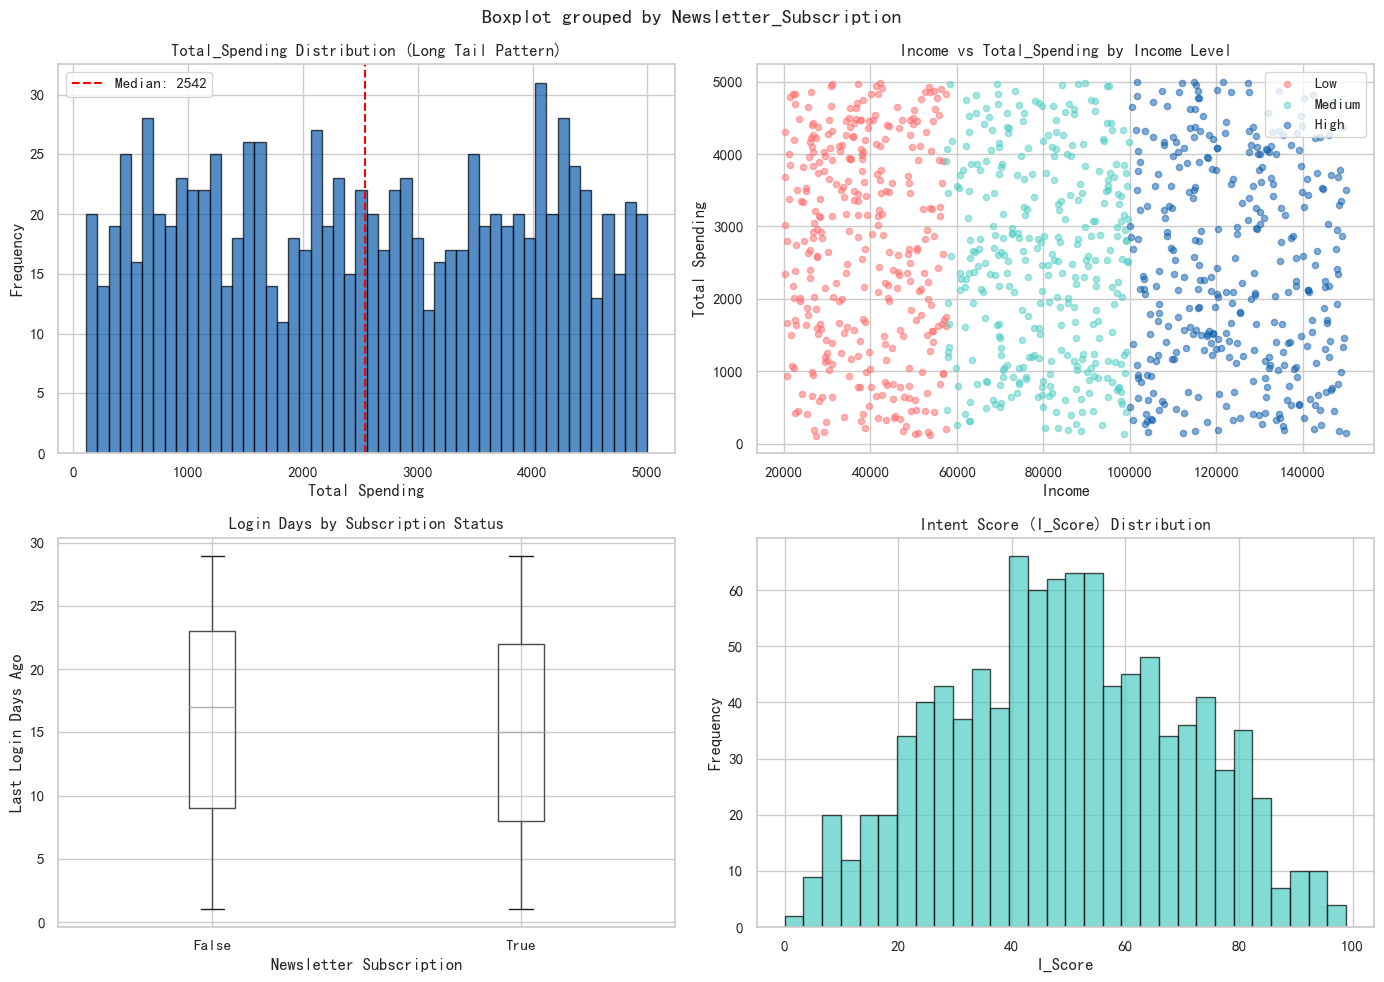

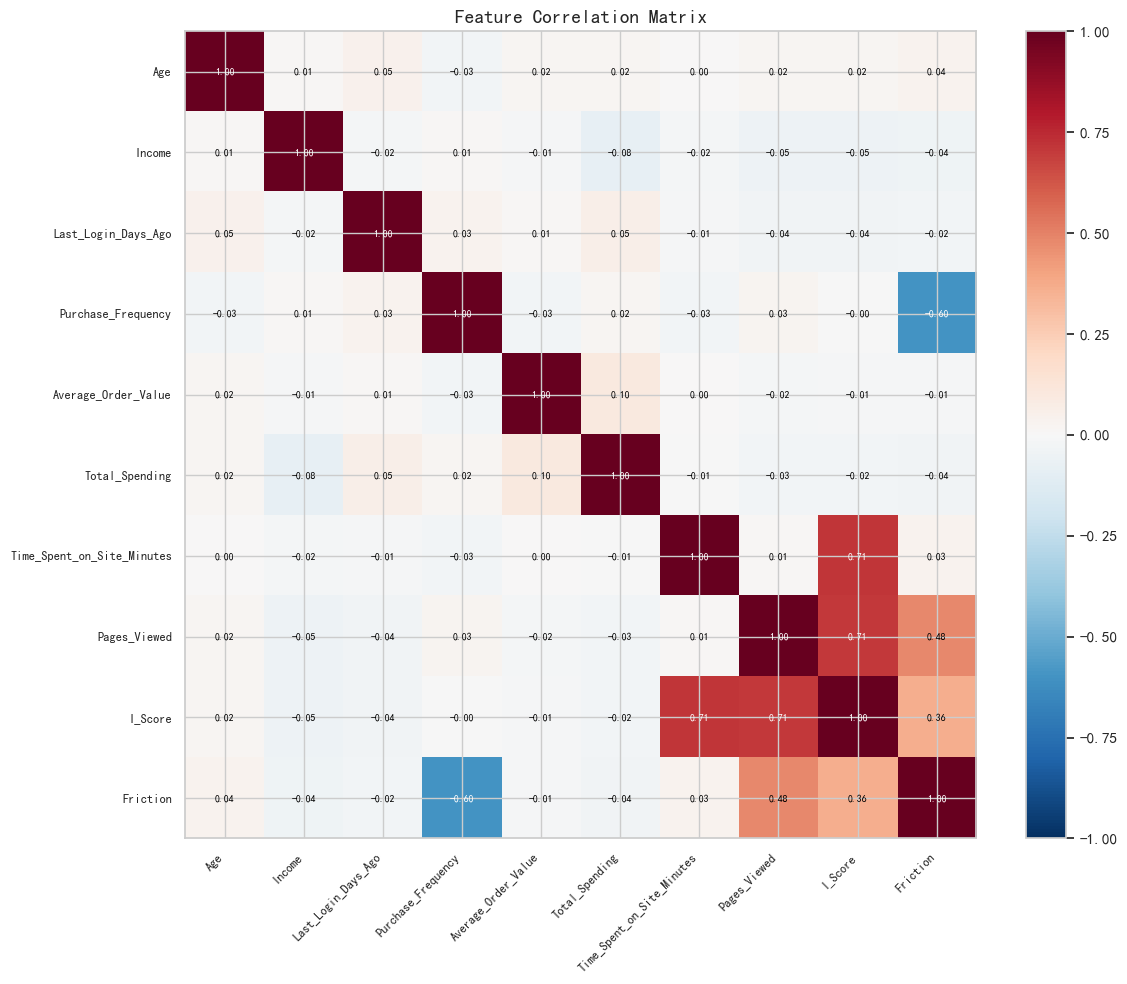


关键相关性分析:
Time_Spent vs Purchase_Frequency 相关系数: -0.028
Pages_Viewed vs Purchase_Frequency 相关系数: 0.026

高摩擦用户(前25%)特征:
  - 平均浏览页数: 34.3
  - 平均购买频率: 1.6
  - 平均消费金额: 2514

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [ ]:
# 5. EDA探索性数据分析
def perform_eda(df, output_dir):
    """EDA分析：分布、相关性、行为洞察"""
    
    print("\n" + "=" * 60)
    print("第三阶段：EDA探索性数据分析")
    print("=" * 60)
    
    # 1. 关键分布分析
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Total_Spending 分布
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--', 
                       label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()
    
    # Income vs Total_Spending 散点图
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()
    
    # Last_Login_Days_Ago vs Newsletter_Subscription 箱线图
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago')
    
    # I_Score 分布
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 2. 相关性分析
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed', 'I_Score', 'Friction']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)
    
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 3. 关键行为洞察
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    
    print(f"\n关键相关性分析:")
    print(f"Time_Spent vs Purchase_Frequency 相关系数: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency 相关系数: {pages_purchase_corr:.3f}")
    
    # 高摩擦用户分析
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\n高摩擦用户(前25%)特征:")
    print(f"  - 平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - 平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - 平均消费金额: {high_friction['Total_Spending'].mean():.0f}")
    
    # 高收入低消费群体
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }

eda_results = perform_eda(df, output_dir)

In [ ]:
# 6. RFM-I模型构建
def build_rfm_model(df):
    """构建RFM-I模型：标准化、综合得分计算"""
    
    print("\n" + "=" * 60)
    print("第四阶段：RFM-I模型构建")
    print("=" * 60)
    
    # 归一化函数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'], reverse=True)
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score']
    df['I_Weight'] = df['I_Score'] / 500  # I_Score 0-100 -> 0-0.2
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight'])
    
    print(f"R_Score 范围: [{df['R_Score'].min():.2f}, {df['R_Score'].max():.2f}]")
    print(f"F_Score 范围: [{df['F_Score'].min():.2f}, {df['F_Score'].max():.2f}]")
    print(f"M_Score 范围: [{df['M_Score'].min():.2f}, {df['M_Score'].max():.2f}]")
    print(f"RFM_Score 范围: [{df['RFM_Score'].min():.2f}, {df['RFM_Score'].max():.2f}]")
    print(f"Final_Score 范围: [{df['Final_Score'].min():.2f}, {df['Final_Score'].max():.2f}]")
    
    return df

df = build_rfm_model(df)
df[['User_ID','R_Score','F_Score','M_Score','I_Score','RFM_Score','Final_Score']].head()


第四阶段：RFM-I模型构建
R_Score 范围: [0.00, 100.00]
F_Score 范围: [0.00, 100.00]
M_Score 范围: [0.00, 100.00]
RFM_Score 范围: [4.72, 96.77]
Final_Score 范围: [5.26, 105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


In [ ]:
# 7. 用户分层与画像
def classify_users(df):
    """用户分层：基于RFM-I模型进行精细化分层"""
    
    print("\n" + "=" * 60)
    print("第五阶段：用户分层与画像")
    print("=" * 60)
    
    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        l = row['L_Score']
        
        # 基础RFM分层逻辑
        if r > 60 and f > 60 and m > 60:
            base_label = "重要价值用户"
        elif r > 60 and m > 60 and f < 40:
            base_label = "重要发展用户"
        elif r < 40 and f > 60 and m > 60:
            base_label = "重要保持用户"
        elif r < 40 and m > 60:
            base_label = "重要挽留用户"
        elif r > 60 and f > 40 and m < 40:
            base_label = "一般发展用户"
        elif r > 60 and f < 40 and m < 40:
            base_label = "一般维持用户"
        elif r < 40 and f < 40 and m < 40:
            base_label = "低价值用户"
        else:
            base_label = "一般用户"
        
        # 关键修正逻辑
        if base_label in ["低价值用户", "一般维持用户"] and income == "High" and i > 60:
            return "高潜沉睡用户"
        if income == "High" and i > 70 and f < 40 and m < 50:
            return "纠结土豪"
        if base_label in ["一般维持用户", "一般发展用户"] and i > 80 and friction > df['Friction'].quantile(0.6):
            return "犹豫型潜力用户"
        if income == "Low" and i > 70 and f < 40:
            return "隐形活跃者"
        if income == "High" and r < 40 and m > 50:
            return "高潜流失客"
        if m > 70 and f > 70 and i > 60:
            return "核心VIP"
        if income == "Low" and i < 40 and m < 40:
            return "羊毛党/低值"
        
        return base_label
    
    df['User_Segment'] = df.apply(classify_user, axis=1)
    
    # 分层统计
    segment_stats = df.groupby('User_Segment').agg({
        'User_ID': 'count',
        'Total_Spending': 'mean',
        'Purchase_Frequency': 'mean',
        'I_Score': 'mean',
        'Income': 'mean',
        'Final_Score': 'mean'
    }).round(2)
    
    segment_stats.columns = ['用户数', '平均消费', '平均购买频率', '平均意向分', '平均收入', '平均综合分']
    segment_stats['占比(%)'] = (segment_stats['用户数'] / len(df) * 100).round(1)
    segment_stats = segment_stats.sort_values('用户数', ascending=False)
    
    print("\n用户分层统计:")
    print(segment_stats.to_string())
    
    return df, segment_stats

df, segment_stats = classify_users(df)


第五阶段：用户分层与画像

用户分层统计:
              用户数     平均消费  平均购买频率  平均意向分       平均收入  平均综合分  占比(%)
User_Segment                                                      
一般用户          443  2368.12    5.17  48.80   84305.72  54.31   44.3
一般发展用户         81  1117.95    6.43  49.84   87107.43  52.67    8.1
重要挽留用户         67  4134.42    2.57  46.53   59698.61  58.59    6.7
高潜流失客          64  3990.70    4.92  44.09  121985.09  65.40    6.4
低价值用户          50  1036.52    1.68  42.79   94734.76  20.87    5.0
重要发展用户         48  3873.96    1.62  48.91   81230.60  65.41    4.8
一般维持用户         47  1055.40    1.47  45.83   91335.23  33.57    4.7
重要价值用户         47  3960.19    7.47  42.28   73500.94  86.82    4.7
重要保持用户         39  4030.23    7.49  48.00   57995.92  75.26    3.9
隐形活跃者          34  2756.79    1.32  77.99   36273.32  47.28    3.4
羊毛党/低值         32  1019.56    5.50  23.08   37896.19  37.05    3.2
核心VIP          23  4171.39    8.17  71.09   59382.39  88.86    2.3
高潜沉睡用户         12  1318.17    1.75  74.

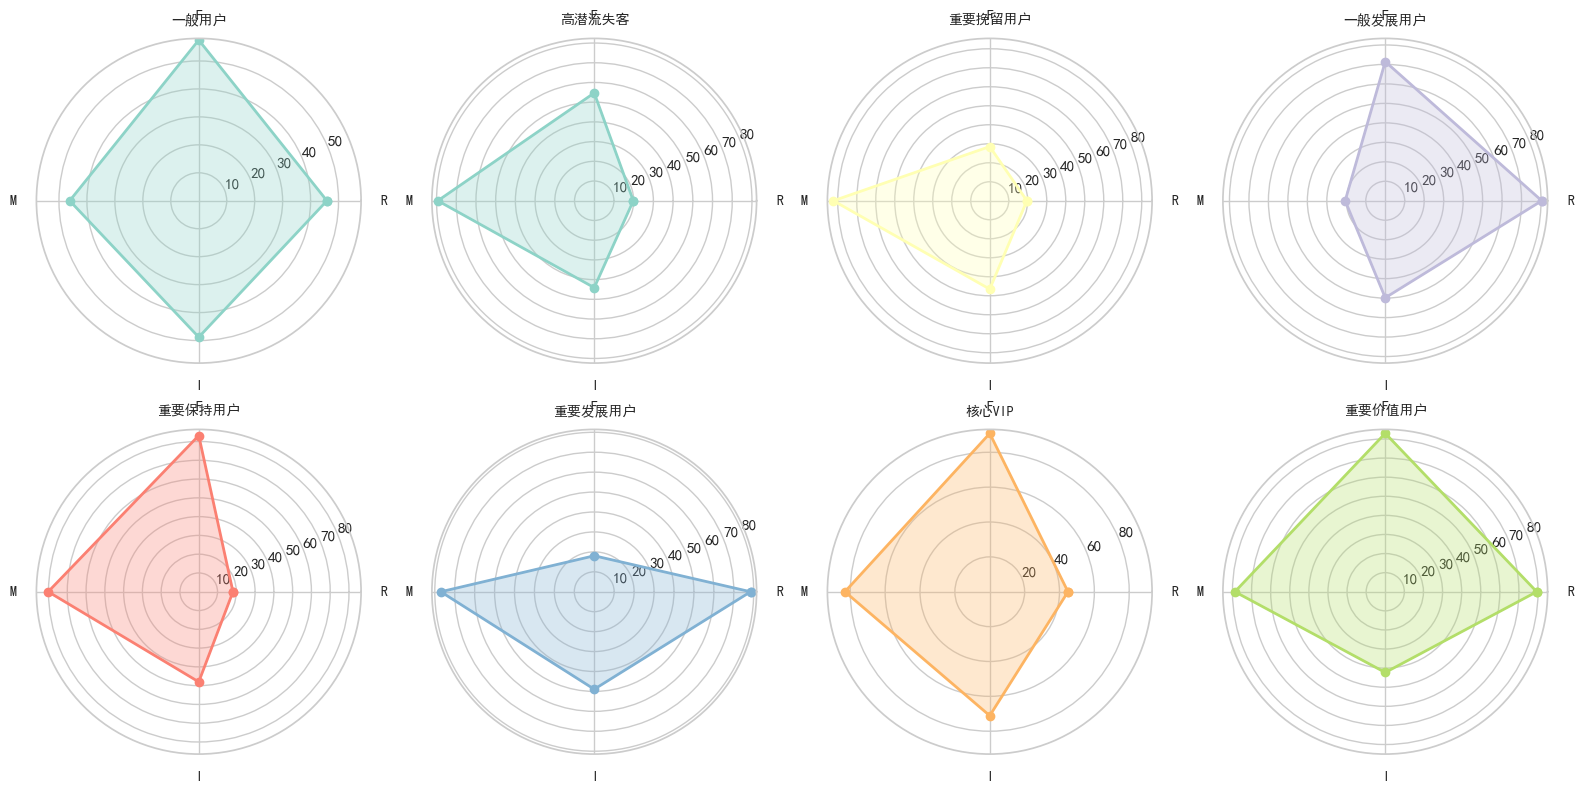

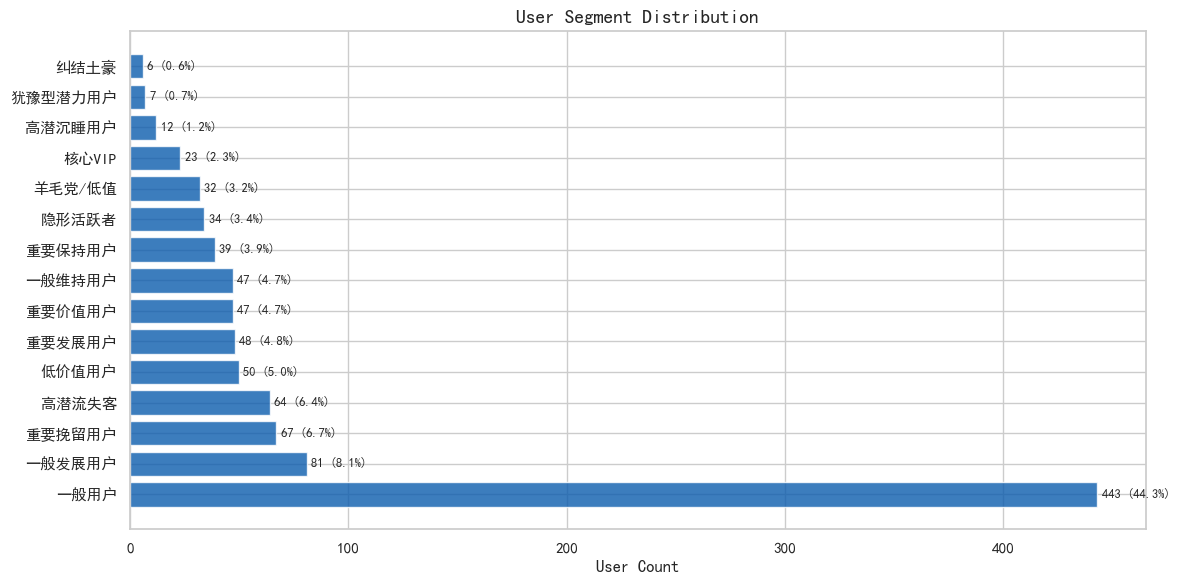

In [ ]:
# 8. 生成用户画像可视化
def generate_segment_portrait(df, output_dir):
    """生成用户画像可视化：雷达图和分布柱状图"""
    
    # 分层雷达图
    segments = df['User_Segment'].unique()
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']
    
    segment_means = df.groupby('User_Segment')[metrics].mean()
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
    
    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]
        
        ax.fill(angles, values, alpha=0.3, color=colors[idx])
        ax.plot(angles, values, 'o-', color=colors[idx], linewidth=2)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R', 'F', 'M', 'I'], fontsize=10)
        ax.set_title(segment, fontsize=10, pad=10)
    
    for idx in range(len(segments), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 分层分布柱状图
    segment_counts = df['User_Segment'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(segment_counts.index, segment_counts.values, color='#0B5CAD', alpha=0.8)
    ax.set_xlabel('User Count')
    ax.set_title('User Segment Distribution', fontsize=14)
    
    for bar, count in zip(bars, segment_counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                f'{count} ({count/len(df)*100:.1f}%)', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

generate_segment_portrait(df, output_dir)


第六阶段：ROI测算

【假设参数】
  总预算: 10000元
  优惠券成本: 10元/人
  平均客单价: 104元

【转化率假设】
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%

【方案A - 传统RFM策略】
  目标用户数: 200
  成本: 2000元
  边际收益（增量）: 2081元
  边际ROI: 4.0%

【方案B - 优化RFI策略】
  核心用户: 70
  新挖掘潜力用户: 89
  总目标用户数: 159
  实际成本: 1590元 (预算使用率: 15.9%)
  边际收益（增量）: 2123元
  边际ROI: 33.5%


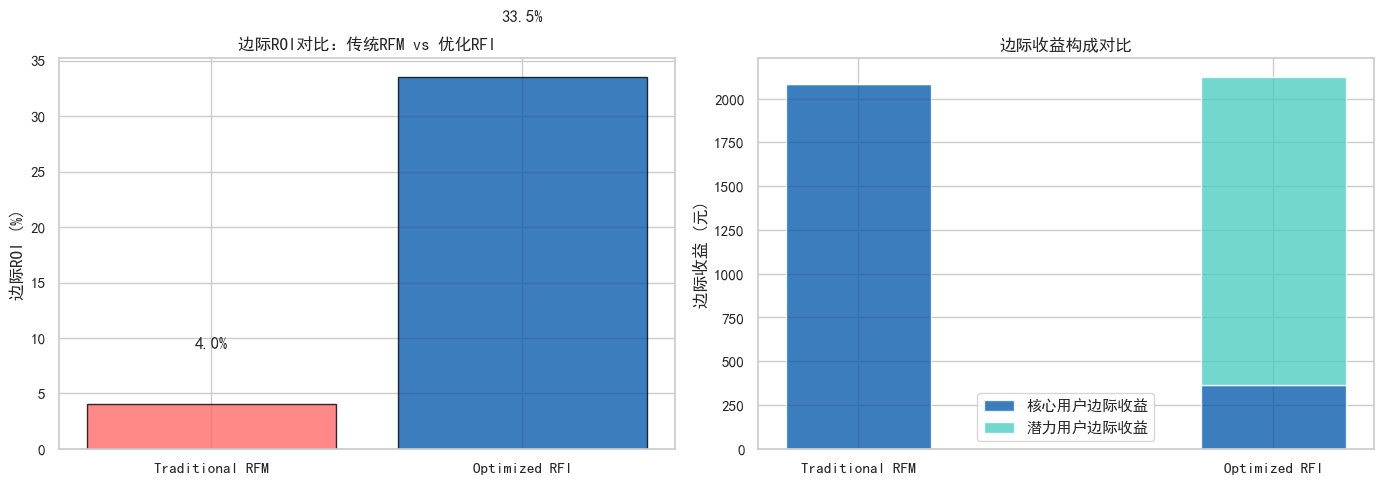

In [ ]:
# 9. ROI测算
def calculate_roi(df, output_dir):
    """ROI测算：传统RFM vs 优化RFI策略对比（边际收益法，参数可调）"""
    
    print("\n" + "=" * 60)
    print("第六阶段：ROI测算")
    print("=" * 60)
    
    # ================= 可调整参数=================
    total_budget = 10000          # 总预算（元）
    coupon_cost = 10               # 每张优惠券成本（元）
    aov = df['Average_Order_Value'].mean()  # 平均客单价（元）
    
    # 转化率假设（可根据历史数据校准）
    # 核心用户
    core_natural = 0.25            # 核心用户无券自然转化率
    core_with_coupon = 0.30        # 核心用户发券后转化率
    # 潜力用户
    potential_natural = 0.01       # 潜力用户自然转化率
    potential_with_coupon = 0.20   # 潜力用户发券后转化率（可调高至20%-25%）
    # 一般用户（用于方案A的基线）
    general_natural = 0.02          # 一般用户自然转化率
    # RFM前20%用户的自然转化率（介于核心和一般之间）
    rfm20_natural = 0.20            # 可根据实际数据调整，例如：RFM高分用户通常转化率较高
    rfm20_with_coupon = 0.30        # 发券后转化率（通常不会超过核心用户）
    
    # 边际提升
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural
    
    # ================= 方案A：传统RFM策略 =================
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]
    target_a_count = min(len(rfm_top20), total_budget // coupon_cost)
    cost_a = target_a_count * coupon_cost
    
    incremental_revenue_a = target_a_count * rfm20_lift * aov
    roi_a = (incremental_revenue_a - cost_a) / cost_a * 100 if cost_a > 0 else 0
    
    # ================= 方案B：优化RFI策略 =================
    core_users = df[df['User_Segment'].isin(['核心VIP', '重要价值用户'])]
    potential_users = df[df['User_Segment'].isin(['纠结土豪', '高潜沉睡用户', '犹豫型潜力用户', '高潜流失客'])]
    
    # 分配预算：优先核心用户（用80%预算），剩余给潜力用户
    core_count = min(len(core_users), int(total_budget * 0.8 / coupon_cost))
    remaining_budget = total_budget - core_count * coupon_cost
    potential_count = min(len(potential_users), remaining_budget // coupon_cost)
    target_b_count = core_count + potential_count
    cost_b = target_b_count * coupon_cost
    
    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) / cost_b * 100 if cost_b > 0 else 0
    
    # ================= 输出结果 =================
    print(f"\n【假设参数】")
    print(f"  总预算: {total_budget}元")
    print(f"  优惠券成本: {coupon_cost}元/人")
    print(f"  平均客单价: {aov:.0f}元")
    
    print(f"\n【转化率假设】")
    print(f"  RFM前20%用户：自然转化率 {rfm20_natural*100:.1f}%，发券后 {rfm20_with_coupon*100:.1f}%，边际提升 {rfm20_lift*100:.1f}%")
    print(f"  核心用户：自然转化率 {core_natural*100:.1f}%，发券后 {core_with_coupon*100:.1f}%，边际提升 {core_lift*100:.1f}%")
    print(f"  潜力用户：自然转化率 {potential_natural*100:.1f}%，发券后 {potential_with_coupon*100:.1f}%，边际提升 {potential_lift*100:.1f}%")
    
    print(f"\n【方案A - 传统RFM策略】")
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元")
    print(f"  边际收益（增量）: {incremental_revenue_a:.0f}元")
    print(f"  边际ROI: {roi_a:.1f}%")
    
    print(f"\n【方案B - 优化RFI策略】")
    print(f"  核心用户: {core_count}")
    print(f"  新挖掘潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(f"  实际成本: {cost_b}元 (预算使用率: {cost_b/total_budget*100:.1f}%)")
    print(f"  边际收益（增量）: {incremental_revenue_b:.0f}元")
    print(f"  边际ROI: {roi_b:.1f}%")
    
    # ROI对比可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 边际ROI对比
    strategies = ['Traditional RFM', 'Optimized RFI']
    rois = [roi_a, roi_b]
    colors = ['#FF6B6B', '#0B5CAD']
    
    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('边际ROI (%)')
    axes[0].set_title('边际ROI对比：传统RFM vs 优化RFI', fontsize=12)
    for bar, roi in zip(bars, rois):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    f'{roi:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # 边际收益构成对比
    x = np.arange(2)
    width = 0.35
    
    core_marginal = [incremental_revenue_a, core_count * core_lift * aov]
    potential_marginal = [0, potential_count * potential_lift * aov]
    
    axes[1].bar(x, core_marginal, width, label='核心用户边际收益', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='潜力用户边际收益', color='#4ECDC4', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('边际收益 (元)')
    axes[1].set_title('边际收益构成对比', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b/total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }
roi_results = calculate_roi(df, output_dir)